<font size="+3">AF3 benchmark on TCR:epitope interactions</font> 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import roc_curve, roc_auc_score

import math
from functools import reduce
import re

# AF3 input

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_81051/2126991102.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_81051/2126991102.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_neg_sub = (df_neg.groupby(

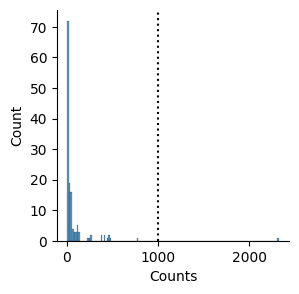

In [25]:
topdir = 'Supplementary_Tables'


df = pd.read_csv(f'{topdir}/Supplementary_Table_1.csv')
df = df.drop(columns=['data_usage', 'CV_id'])
df = df.drop_duplicates()

df_pos = df[(df['dataset_source'] == 'Public Paired Data') & (df['Label'] == 1)]
df_neg = df[(df['dataset_source'] == 'Public TCRs with undetermined specificities') & (df['Label'] == 0)]

counts = df_pos['Epitope'].value_counts().reset_index()
counts.columns = ['Epitope', 'Counts']

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.histplot(data=counts, x='Counts', ax=ax)
ax.axvline(1000, color='black', linestyle=':')
sns.despine()

# subsample positives n > 1000
df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
df_pos_sub.to_csv('positives.csv', index=False)

# how many positives per epitope after subsampling
pos_counts = df_pos_sub['Epitope'].value_counts()

# sample matching number of negatives per epitope
df_neg_sub = (df_neg.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), pos_counts.get(x.name, 0)), random_state=42)).reset_index(drop=True))
df_neg_sub.to_csv('negatives.csv', index=False)

In [ ]:
batches = ['positives', 'negatives']
exclude_mhc = ['DRB10101', 'DRB10701', 'DRB11501', 'na']

for batch in batches:
    os.makedirs(batch, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['Label', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]
    
    # exclude unclear mhcs
    df = df[~df['MHC'].isin(exclude_mhc)]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # first allele always exists
    df['MHC_allele_a'] = 'HLA_' + mhc_split[0]

    # second allele only exists for entries with '-'
    df['MHC_allele_b'] = mhc_split[1]
    df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')
    df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'
    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    # for now only class I
    df = df[df['MHC_allele_b'] == 'NA']
    df = df.drop(columns=['MHC_allele_b'])
    print(np.unique(df['MHC_allele_a']))
    df.to_csv(f'{batch}/AF3_class_I.csv', index=False)
    print(len(df))

10318
9018
['A0101' 'A0201' 'B0702' 'B0801' 'B1501' 'B4001' 'B5701'
 'DPA10103-DPB10401' 'DQA10102-DQB10602' 'DQA10102-DQB10603'
 'DQA10301-DQB10302' 'DQA10501-DQB10201']
10318
9018
['A0101' 'A0201' 'B0702' 'B0801' 'B1501' 'B4001' 'B5701'
 'DPA10103-DPB10401' 'DQA10102-DQB10602' 'DQA10102-DQB10603'
 'DQA10301-DQB10302' 'DQA10501-DQB10201']


"\n    # split alpha/beta if present\n    mhc_split = df['MHC'].str.split('-', n=1, expand=True)\n\n    # first allele always exists\n    df['MHC_allele_a'] = 'HLA_' + mhc_split[0]\n\n    # second allele only exists for entries with '-'\n    df['MHC_allele_b'] = mhc_split[1]\n    df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')\n    df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'\n    df = df.drop(columns=['Epitope', 'MHC'])\n\n    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])\n    df.insert(0, 'id', tcr_ids)\n\n    # for now only class I\n    df = df[df['MHC_allele_b'] == 'NA']\n    df = df.drop(columns=['MHC_allele_b'])\n    print(np.unique(df['MHC_allele_a']))\n    df.to_csv(f'{batch}/AF3_class_I.csv', index=False)\n    print(len(df))\n"

In [26]:
batches = ['positives', 'negatives']
weirdos = ['DRB10101', 'DRB10701', 'DRB11501']

for batch in batches:
    os.makedirs(batch, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['Label', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]

    # exclude unclear mhcs / class I
    df = df[~(df['MHC'] == 'na')]
    df = df[df['MHC'].str.startswith('D')]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # mask for rows with two alleles
    has_two = mhc_split[1].notna()

    # mask for weird single-chain cases
    is_weirdo = mhc_split[0].isin(weirdos)

    # initialize columns
    df['MHC_allele_a'] = None
    df['MHC_allele_b'] = None

    # Case 1: two alleles
    df.loc[has_two, 'MHC_allele_a'] = 'HLA_' + mhc_split[0]
    df.loc[has_two, 'MHC_allele_b'] = 'HLA_' + mhc_split[1]

    # Case 2: weird single allele (e.g. DRB only → pair with DRA)
    df.loc[~has_two & is_weirdo, 'MHC_allele_a'] = 'HLA_DRA_01_01'
    df.loc[~has_two & is_weirdo, 'MHC_allele_b'] = 'HLA_' + mhc_split[0]

    def format_hla(x):
        if pd.isna(x):
            return x
        return re.sub(r'(\d{1,})(\d{2})(\d{2})$', r'\1_\2_\3', x)

    df['MHC_allele_a'] = df['MHC_allele_a'].apply(format_hla)
    df['MHC_allele_b'] = df['MHC_allele_b'].apply(format_hla)

    print(np.unique(df['MHC_allele_a']))
    print(np.unique(df['MHC_allele_b']))

    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    df.to_csv(f'{batch}/AF3_class_II.csv', index=False)
    print(len(df))

['HLA_DPA1_01_03' 'HLA_DQA1_01_02' 'HLA_DQA1_03_01' 'HLA_DQA1_05_01'
 'HLA_DRA_01_01']
['HLA_DPB1_04_01' 'HLA_DQB1_02_01' 'HLA_DQB1_03_02' 'HLA_DQB1_06_02'
 'HLA_DQB1_06_03' 'HLA_DRB1_01_01' 'HLA_DRB1_07_01' 'HLA_DRB1_15_01']
1006
['HLA_DPA1_01_03' 'HLA_DQA1_01_02' 'HLA_DQA1_03_01' 'HLA_DQA1_05_01'
 'HLA_DRA_01_01']
['HLA_DPB1_04_01' 'HLA_DQB1_02_01' 'HLA_DQB1_03_02' 'HLA_DQB1_06_02'
 'HLA_DQB1_06_03' 'HLA_DRB1_01_01' 'HLA_DRB1_07_01' 'HLA_DRB1_15_01']
1006


# Analyze AF3 output

In [24]:
mhcs = ['class_I', 'class_II']
batches = ['positives', 'negatives']

for mhc in mhcs:
    lst = []
    for batch in batches:
        if mhc == 'class_I':
            df_input = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_input.txt', sep='\t')[['id', 'peptide', 'MHC_allele_a']]
            df_input['epitope'] = df_input['MHC_allele_a'].str[4:] + '_' + df_input['peptide']
        else:
            df_input = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_input.txt', sep='\t')[['id', 'peptide', 'MHC_allele_a', 'MHC_allele_b']]
            df_input["MHC_allele_a"] = df_input["MHC_allele_a"].str.replace("_", "", regex=False)
            df_input["MHC_allele_b"] = df_input["MHC_allele_b"].str.replace("_", "", regex=False)
            df_input['epitope'] = df_input['MHC_allele_a'].str[3:] + '-' + df_input['MHC_allele_b'].str[3:] + '_' + df_input['peptide']

        df_output = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
        
        df = pd.merge(df_input, df_output, on='id')
        df['batch'] = batch
        lst.append(df)

    df = pd.concat(lst)
    df.to_csv(f'AF3_{mhc}_output.csv', index=False)
    print(df.head())

          id    peptide MHC_allele_a          epitope  AF3_iptm_pair_mean  \
0  tcr_00001  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.6275   
1  tcr_00002  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.7075   
2  tcr_00003  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.6250   
3  tcr_00004  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.8825   
4  tcr_00005  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.4375   

       batch  
0  positives  
1  positives  
2  positives  
3  positives  
4  positives  
          id         peptide MHC_allele_a MHC_allele_b  \
0  tcr_00001  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
1  tcr_00002  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
2  tcr_00003  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
3  tcr_00004  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
4  tcr_00005  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   

                            epitope  AF3_iptm_pair_mean      batch  
0  DPA10103-DPB10401_TFEYVSQP

            epitope  n_samples  n_samples_iptm_0.5  n_samples_iptm_0.8  \
0   A0101_ATDALMTGF        129                  85                  30   
1   A0101_CTELKLSDY        124                  80                  17   
2  A0101_FTDALGIDEY         12                  12                   3   
3   A0101_FTSDYYQLY         44                  19                   6   
4   A0101_HSNLNDATY         26                  19                   3   

        auc     auc01  
0  0.658764  0.562474  
1  0.719661  0.586464  
2  0.850694  0.616228  
3  0.659884  0.582452  
4  0.876479  0.802242  
                             epitope  n_samples  n_samples_iptm_0.5  \
0   DPA10103-DPB10401_TFEYVSQPFLMDLE        784                 204   
1  DQA10102-DQB10602_AMERNAGSGIIISDT         10                   7   
2    DQA10102-DQB10602_ERNAGSGIIISDT         10                   9   
3  DQA10102-DQB10602_GTRVIRDMTLHSAPS         47                  36   
4  DQA10102-DQB10603_PNANPNVDPNANPNV         10         

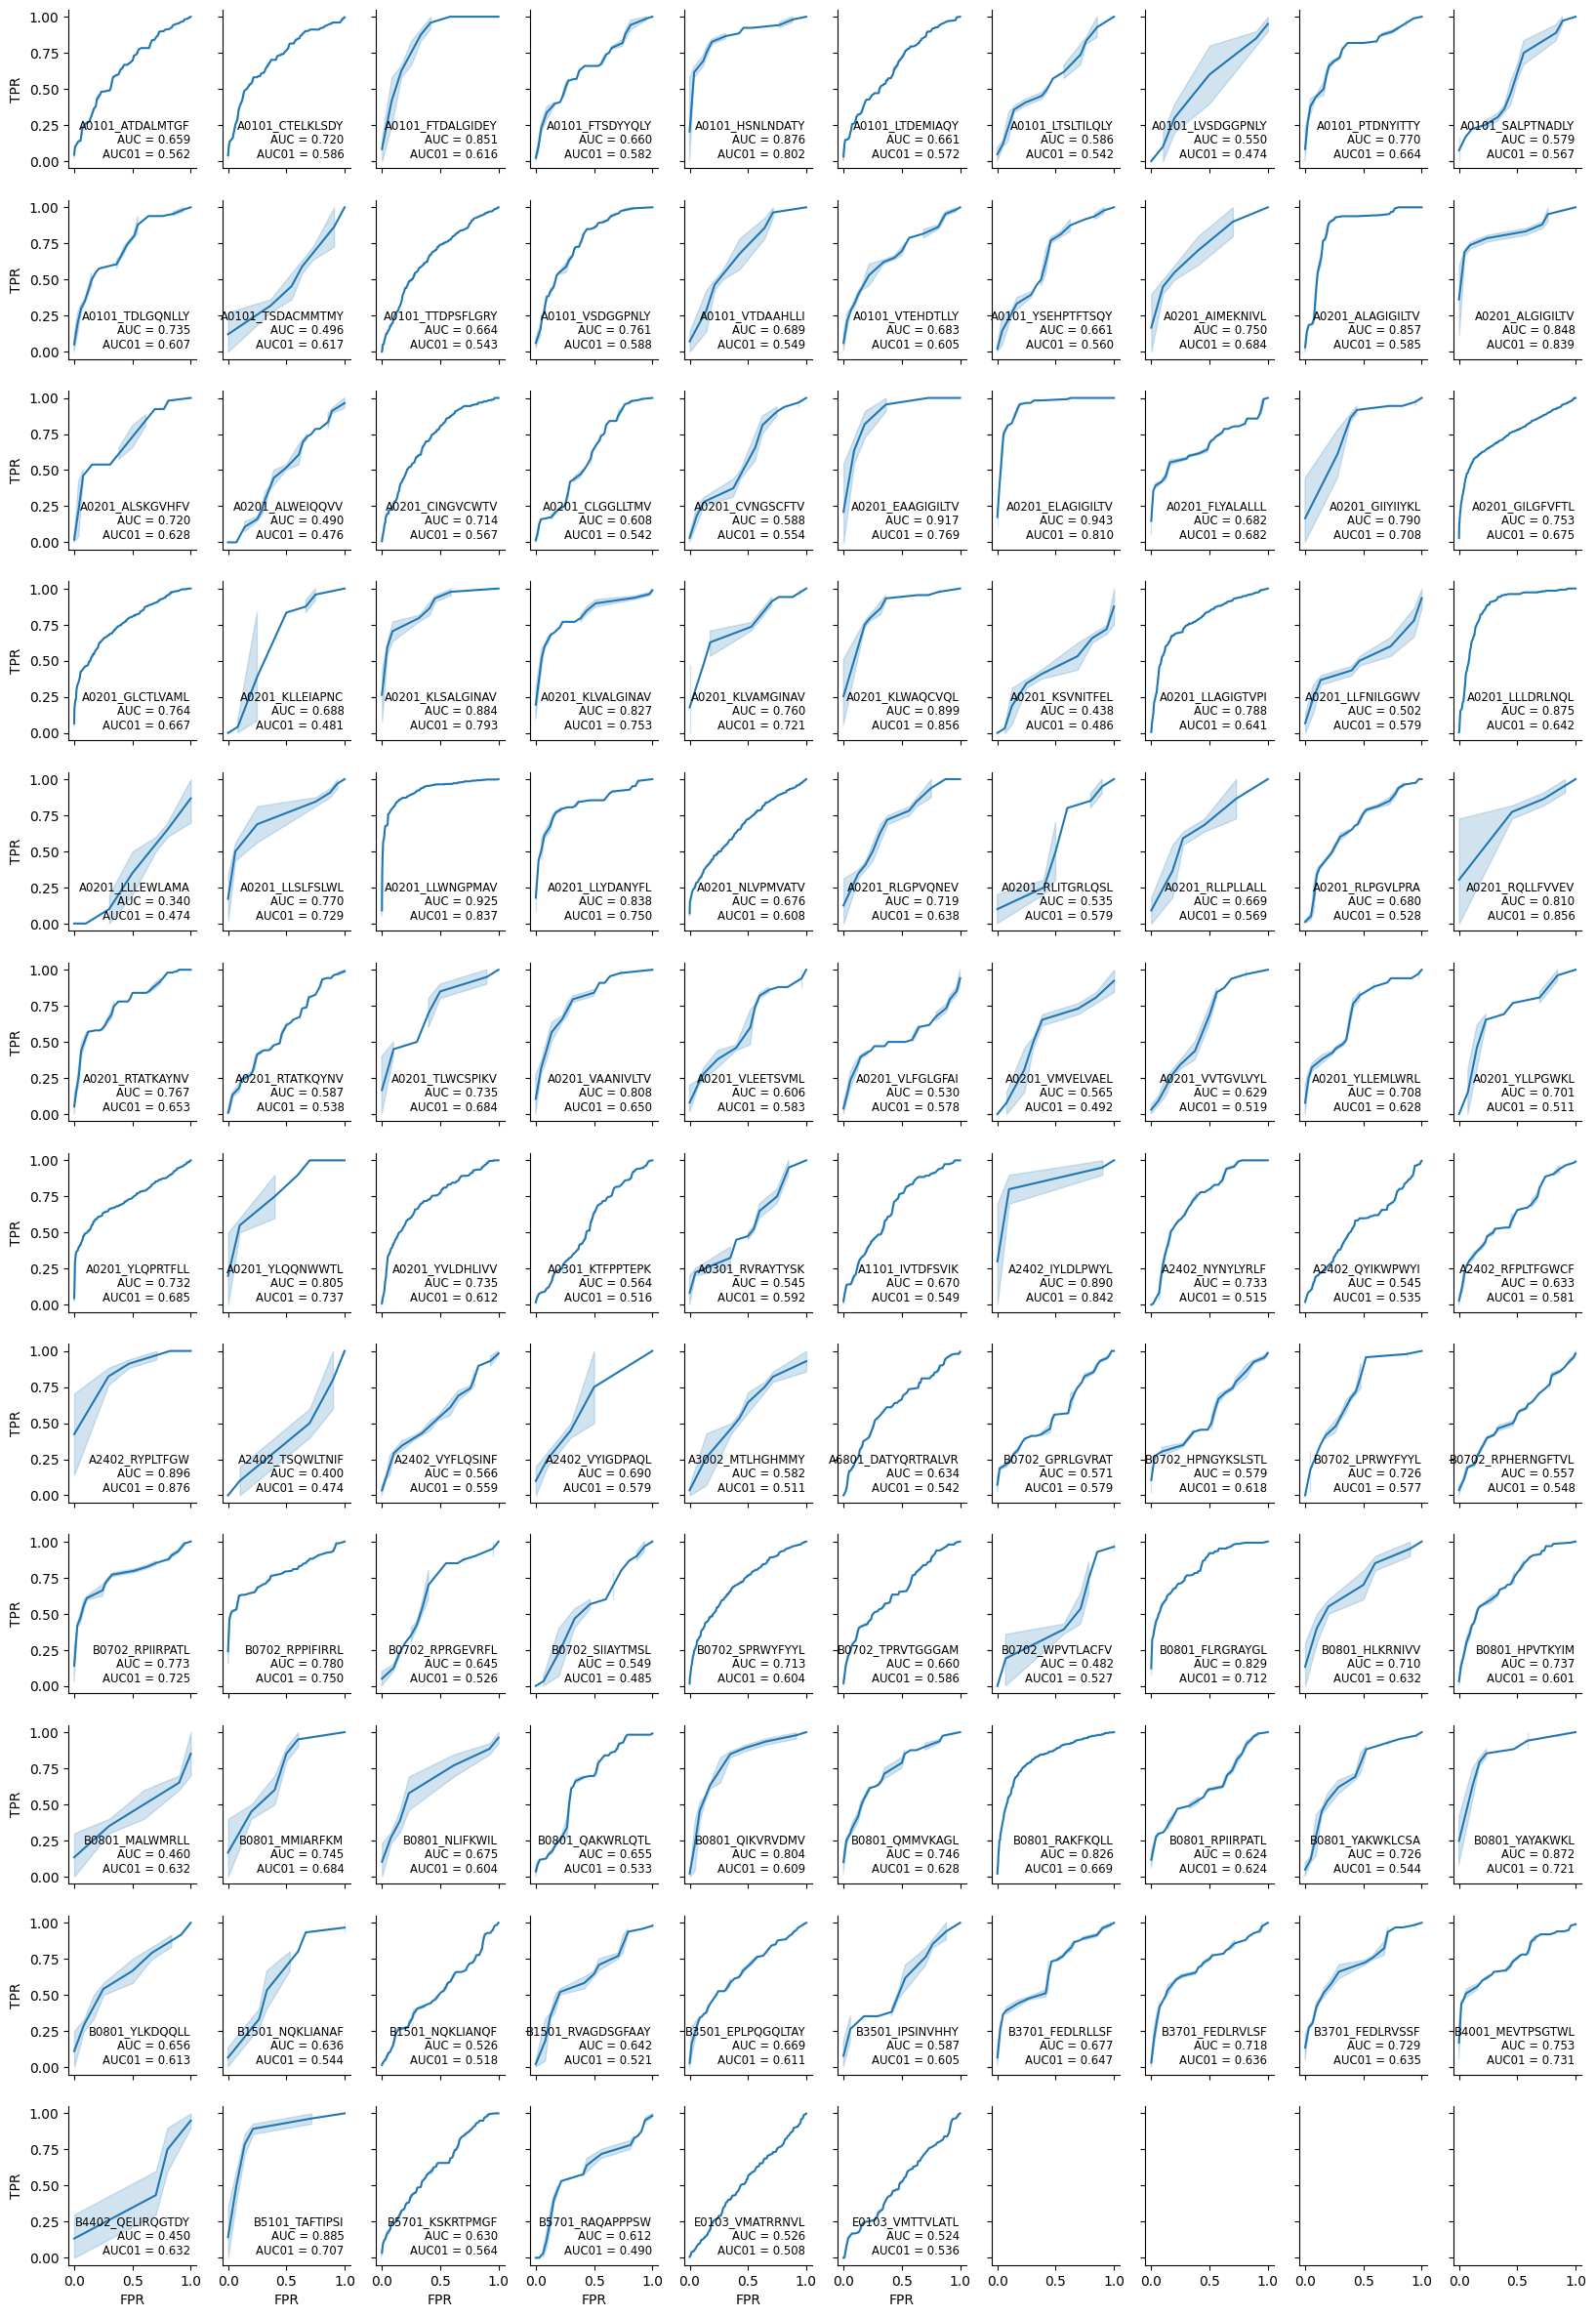

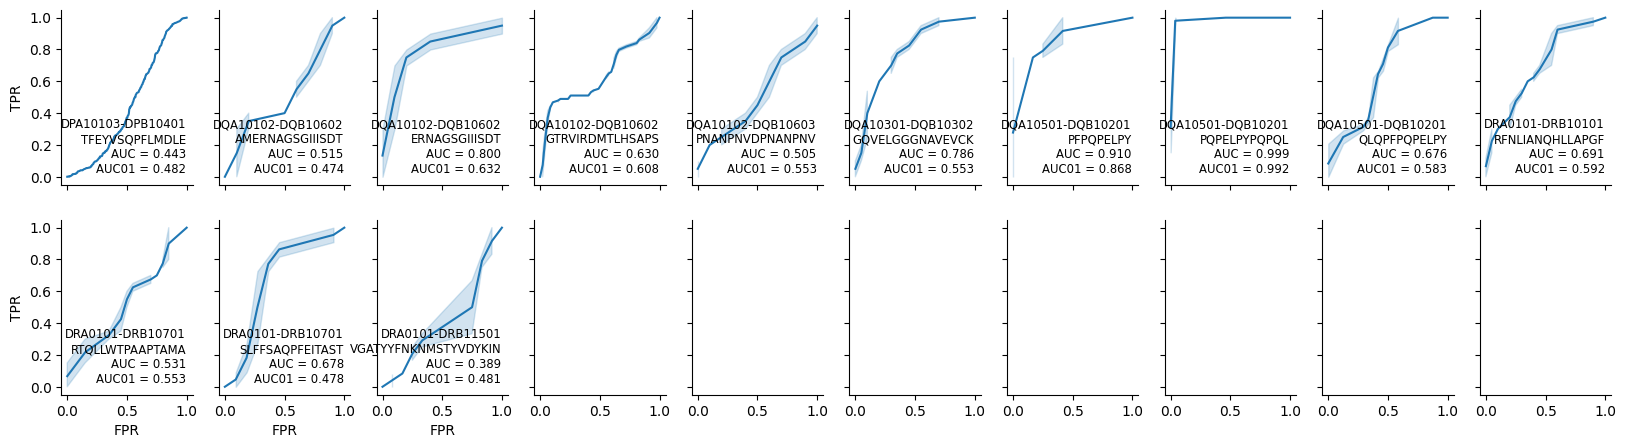

In [25]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_output.csv')

    if mhc == 'class_I':
        fig, axes = plt.subplots(12, 10, figsize=(20, 30), sharex=True, sharey=True)
    else:
        fig, axes = plt.subplots(2, 10, figsize=(20, 5), sharex=True, sharey=True)

    dico = {
        'epitope': [],
        'n_samples': [],
        'n_samples_iptm_0.5': [],
        'n_samples_iptm_0.8': [],
        'auc': [],
        'auc01': [],
    }

    for cnt, (name, group) in enumerate(df.groupby('epitope')):
        row = cnt // 10
        col = cnt % 10
        ax = axes[row, col]

        # correct filtering (use group, not df)
        scores_pos = group.loc[group['batch'] == 'positives', 'AF3_iptm_pair_mean'].values
        scores_neg = group.loc[group['batch'] == 'negatives', 'AF3_iptm_pair_mean'].values

        # skip invalid cases
        if len(scores_pos) == 0 or len(scores_neg) == 0:
            continue

        # labels + scores
        y_true = np.concatenate([
            np.ones(len(scores_pos)),
            np.zeros(len(scores_neg))
        ])
        y_scores = np.concatenate([scores_pos, scores_neg])

        # ROC + metrics
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_full = roc_auc_score(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # tandardized AUC01

        # plot
        sns.lineplot(x=fpr, y=tpr, ax=ax)

        if mhc == 'class_I':
            label = f"{name}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"
        else:
            mhc_peptide = name.split('_')
            label = f"{mhc_peptide[0]}\n{mhc_peptide[1]}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

        ax.text(
            0.95, 0.05,
            label,
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize='small'
        )

        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        sns.despine()

        # store results
        dico['epitope'].append(name)
        dico['n_samples'].append(len(scores_pos))
        dico['n_samples_iptm_0.5'].append((scores_pos > 0.5).sum())
        dico['n_samples_iptm_0.8'].append((scores_pos > 0.8).sum())
        dico['auc'].append(auc_full)
        dico['auc01'].append(auc01)

    # save results
    df_auc = pd.DataFrame(dico)
    df_auc.to_csv(f'AF3_{mhc}_auc.csv', index=False)
    print(df_auc.head())

10
10
10
10
10
10


/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_47266/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_47266/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_47266/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)


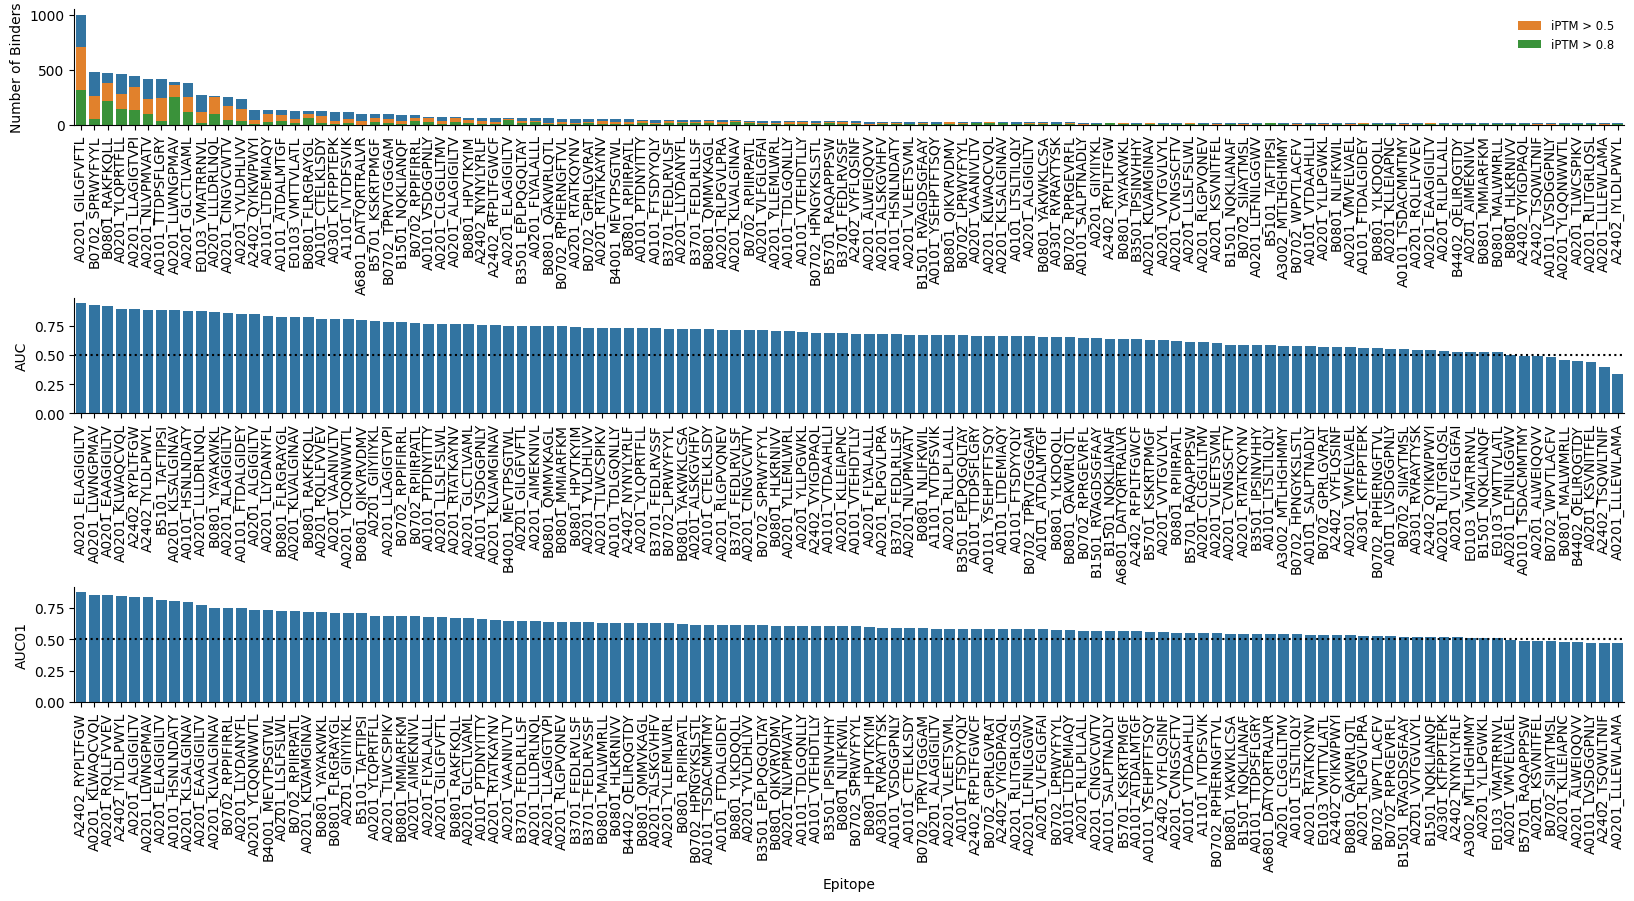

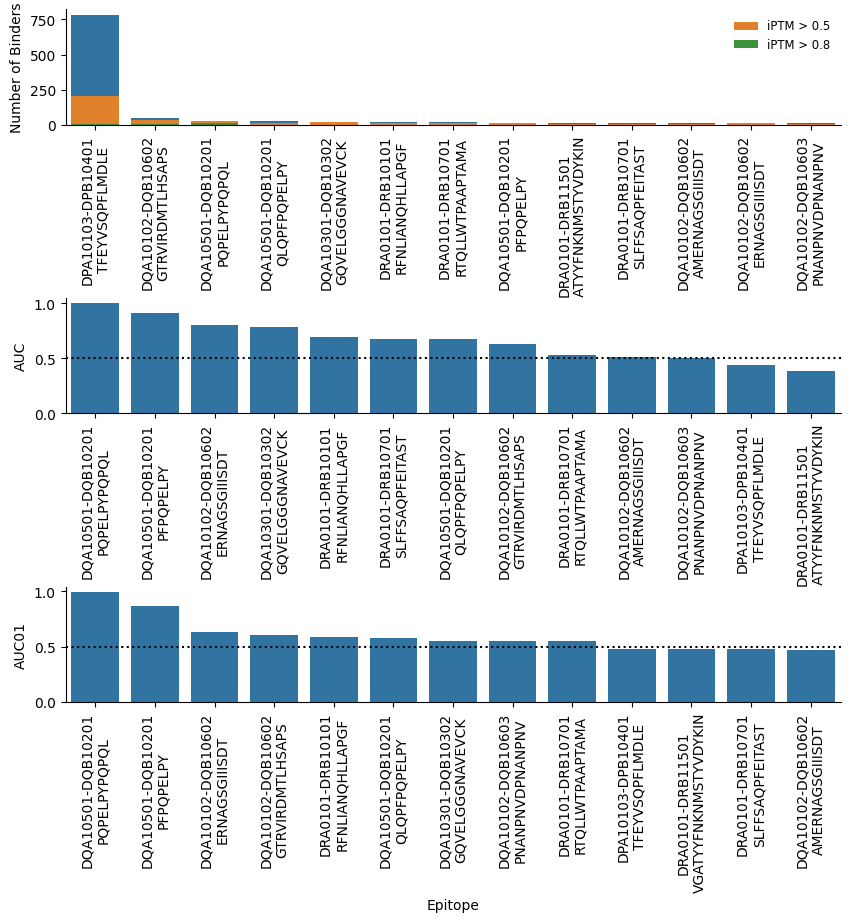

In [29]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')

    
    if mhc == 'class_I':
        fig, axes = plt.subplots(3, 1, figsize=(20,9))
        fig.subplots_adjust(hspace=1.5)
    else:
        fig, axes = plt.subplots(3, 1, figsize=(10,9))
        fig.subplots_adjust(hspace=1.5)

    df = df.sort_values(by='n_samples', ascending=False)
    sns.barplot(df, x='epitope', y='n_samples', ax=axes[0])
    sns.barplot(df, x='epitope', y='n_samples_iptm_0.5', ax=axes[0], label = 'iPTM > 0.5')
    sns.barplot(df, x='epitope', y='n_samples_iptm_0.8', ax=axes[0], label = 'iPTM > 0.8')
    axes[0].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[0].set_xlabel('Epitope')
    axes[0].set_ylabel('Number of Binders')
    axes[0].legend(frameon=False, fontsize='small')

    df = df.sort_values(by='auc', ascending=False)
    sns.barplot(df, x='epitope', y='auc', ax=axes[1])
    axes[1].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[1].set_xlabel('Epitope')
    axes[1].set_ylabel('AUC')
    axes[1].axhline(0.5, color='black', linestyle=':')

    df = df.sort_values(by='auc01', ascending=False)
    sns.barplot(df, x='epitope', y='auc01', ax=axes[2])
    axes[2].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[2].set_xlabel('Epitope')
    axes[2].set_ylabel('AUC01')
    axes[2].axhline(0.5, color='black', linestyle=':')

    if mhc == 'class_II':
        for ax in axes:
            labels = [tick.get_text() for tick in ax.get_xticklabels()]
            new_labels = [lbl.replace("_", "\n") for lbl in labels]
            ax.set_xticklabels(new_labels, rotation=90)

    sns.despine()

# TCR motifs

In [51]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    # average motif based on iptm threshold
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')

    target = 1000
    df['factor'] = target // df['n_samples']
    df = df.rename(columns={'epitope':'model'})
    df.to_csv(f'AF3_{mhc}_factor.csv', index=False)
    print(df.head())

              model  n_samples  n_samples_iptm_0.5  n_samples_iptm_0.8  \
0   A0101_ATDALMTGF        129                  85                  30   
1   A0101_CTELKLSDY        124                  80                  17   
2  A0101_FTDALGIDEY         12                  12                   3   
3   A0101_FTSDYYQLY         44                  19                   6   
4   A0101_HSNLNDATY         26                  19                   3   

        auc     auc01  factor  
0  0.658764  0.562474       7  
1  0.719661  0.586464       8  
2  0.850694  0.616228      83  
3  0.659884  0.582452      22  
4  0.876479  0.802242      38  
                               model  n_samples  n_samples_iptm_0.5  \
0   DPA10103-DPB10401_TFEYVSQPFLMDLE        784                 204   
1  DQA10102-DQB10602_AMERNAGSGIIISDT         10                   7   
2    DQA10102-DQB10602_ERNAGSGIIISDT         10                   9   
3  DQA10102-DQB10602_GTRVIRDMTLHSAPS         47                  36   
4  DQA10

In [52]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_output.csv')
    df = df[df['batch'] == 'positives']
    anno = pd.read_csv(f'{mhc}/positives/AF3_{mhc}_input.txt', sep='\t')[['id', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB']]

    df = pd.merge(df, anno, on='id')
    df = df.drop(columns=['batch'])
    
    df_auc = pd.read_csv(f'AF3_{mhc}_auc.csv')[['epitope', 'auc', 'auc01']]
    df = pd.merge(df, df_auc, on='epitope')
    df = df.rename(columns={'epitope':'model'})
    df.to_csv(f'AF3_{mhc}_motif.csv', index=False)

    if mhc == 'class_I':
        df = df[(df['model'].str.startswith('A0201_ELAG')) | (df['model'].str.startswith('A0201_GILG'))]
        print(np.unique(df['model']))
        df.to_csv(f'test.csv', index=False)
        print(df.head())

['A0201_ELAGIGILTV' 'A0201_GILGFVFTL']
             id     peptide MHC_allele_a             model  \
1661  tcr_01662  ELAGIGILTV    HLA_A0201  A0201_ELAGIGILTV   
1662  tcr_01663  ELAGIGILTV    HLA_A0201  A0201_ELAGIGILTV   
1663  tcr_01664  ELAGIGILTV    HLA_A0201  A0201_ELAGIGILTV   
1664  tcr_01665  ELAGIGILTV    HLA_A0201  A0201_ELAGIGILTV   
1665  tcr_01666  ELAGIGILTV    HLA_A0201  A0201_ELAGIGILTV   

      AF3_iptm_pair_mean      TRAV    TRAJ         cdr3_TRA      TRBV  \
1661              0.7350    TRAV35  TRAJ49      CAGGTGNQFYF  TRBV10-3   
1662              0.8750  TRAV12-2  TRAJ48     CAVSFGNEKLTF    TRBV28   
1663              0.8350  TRAV12-3  TRAJ48  CAMTQSNFGNEKLTF    TRBV27   
1664              0.8675  TRAV12-2  TRAJ45     CAVGGGADGLTF   TRBV6-5   
1665              0.6550  TRAV12-2  TRAJ48      CAVNRNEKLTF     TRBV2   

         TRBJ         cdr3_TRB       auc     auc01  
1661  TRBJ1-5   CAISEVGVGQPQHF  0.943367  0.809658  
1662  TRBJ1-5   CAEGQGFVGQPQHF  0.943367  0

,epitope,n_samples,n_samples_iptm_0.5,n_samples_iptm_0.8,auc,auc01
7,DQA10501-DQB10201_PQPELPYPQPQL,26,26,10,0.998521,0.992214
6,DQA10501-DQB10201_PFPQPELPY,12,10,1,0.909722,0.868421
2,DQA10102-DQB10602_ERNAGSGIIISDT,10,9,1,0.800000,0.631579
5,DQA10301-DQB10302_GQVELGGGNAVEVCK,20,16,0,0.786250,0.552632
9,DRA0101-DRB10101_RFNLIANQHLLAPGF,20,15,0,0.691250,0.592105
11,DRA0101-DRB10701_SLFFSAQPFEITAST,11,8,1,0.677686,0.478034
8,DQA10501-DQB10201_QLQPFPQPELPY,24,15,0,0.676215,0.583333
3,DQA10102-DQB10602_GTRVIRDMTLHSAPS,47,36,6,0.630149,0.608170
10,DRA0101-DRB10701_RTQLLWTPAAPTAMA,20,13,0,0.531250,0.552632
1,DQA10102-DQB10602_AMERNAGSGIIISDT,10,7,0,0.515000,0.473684
